# Tutorial: Data Bootstrapping With Regime States

This notebook is the practical version of the regime-bootstrap guide. It shows how to generate artificial OHLC paths while respecting simple market-state labels.

The workflow is:

1. Build or infer one hard state label for each generated bar.
2. Estimate state frequencies and state-to-state transitions from those labels.
3. Generate a synthetic state path.
4. Sample empirical prepared OHLC rows from the matching state buckets.
5. Reconstruct synthetic OHLC data.

Use this to stress a strategy across plausible state sequences. Do not treat it as independent proof: the generated paths are still based on the original sample and on your chosen state definitions.

## Data source

The examples use continuous NQ futures from the local Arctic store:

```python
store = ArcticStore("contfutures")
df = store.store.read("NQ")
df = df.loc["2023-06-01":]
```

Any other OHLC dataframe can be substituted. The examples expect at least `open`, `high`, `low`, and `close`; `volume` and `barCount` are used when available.

## At-a-glance review

- Problem: one historical path can make a strategy look better than it is. Bootstrap paths provide extra development scenarios before the final real holdout test.
- Regime idea: label each bar with a simple market condition, such as trend direction and volatility level.
- Generator behavior: it creates a synthetic state path, then samples observed rows from the matching historical state bucket.
- Main risk: bad or tiny state buckets produce weak synthetic data. Inspect `states.value_counts()` before trusting custom state paths.
- Default input: `regime_bootstrap(df)` works without a `states` series by using `return_states(df)`, which labels bars by positive or negative close-to-close log return.

In [1]:
import numpy as np
import pandas as pd

from haymaker.datastore import ArcticStore

store = ArcticStore("contfutures")
item = store.store.read("NQ")
df = item.data if hasattr(item, "data") else item
df = df.loc["2023-06-01":].copy()
df = df.sort_index()

df.head()

/home/tomek/.virtualenvs/new_ib/lib/python3.12/site-packages/arctic/__init__.py:12: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution
Library created, but couldn't enable sharding: no such command: 'enablesharding', full error: {'ok': 0.0, 'errmsg': "no such command: 'enablesharding'", 'code': 59, 'codeName': 'CommandNotFound'}. This is OK if you're not 'admin'


,open,high,low,close,volume,average,barCount
date,,,,,,,
2023-06-01 00:00:00+00:00,17073.25,17073.50,17070.75,17072.75,81.0,17072.125,65
2023-06-01 00:00:30+00:00,17072.25,17072.50,17071.25,17071.25,13.0,17071.925,10
2023-06-01 00:01:00+00:00,17071.00,17072.75,17067.75,17070.00,82.0,17069.975,53
2023-06-01 00:01:30+00:00,17069.75,17070.25,17068.25,17069.75,61.0,17069.050,48
2023-06-01 00:02:00+00:00,17070.50,17073.50,17070.50,17072.75,59.0,17072.375,45


In [2]:
required = ["open", "high", "low", "close"]
optional = [column for column in ["volume", "barCount", "average"] if column in df.columns]
df = df[required + optional].dropna().copy()

# The NQ 30-second slice is large. Keep the tutorial responsive; set this
# to None if you want to run every example on the full history.
max_rows = 100_000
if max_rows is not None and len(df) > max_rows:
    df = df.tail(max_rows).copy()

df.tail()

,open,high,low,close,volume,barCount,average
date,,,,,,,
2026-03-24 08:32:30+00:00,24405.00,24407.25,24395.50,24398.50,100.0,65,24403.250
2026-03-24 08:33:00+00:00,24401.50,24404.75,24395.50,24397.75,57.0,46,24400.575
2026-03-24 08:33:30+00:00,24396.25,24402.25,24385.25,24387.25,78.0,60,24394.300
2026-03-24 08:34:00+00:00,24387.75,24395.75,24387.75,24391.75,39.0,35,24392.900
2026-03-24 08:34:30+00:00,24391.25,24399.25,24391.25,24396.00,31.0,26,24395.875


## Rule-based states

The default call is intentionally simple:

```python
paths = regime_bootstrap(df, paths=3, random_state=7)
```

That uses `return_states(df)` internally. For more controlled experiments, the simple helpers return state series, and `combine_states()` joins them into tuple labels that are directly feedable into `regime_bootstrap()`.

The compact explicit-state version is:

```python
paths = regime_bootstrap(
    df,
    states=combine_states(trend_states(df), volatility_states(df)),
    paths=3,
    random_state=7,
)
```

In a real notebook, keep the state-building step separate so you can inspect the bucket sizes before generating paths.

In [3]:
from haymaker.research.bootstrap import (
    combine_states,
    hmm_states,
    regime_bootstrap,
    trend_states,
    volatility_states,
    range_states,
    return_states,
)

trend = trend_states(df, window=80)
volatility = volatility_states(df, window=40)
states = combine_states(trend, volatility)

states.value_counts().head(10)

/home/tomek/.virtualenvs/new_ib/lib/python3.12/site-packages/pyfolio/pos.py:25: UserWarning: Module "zipline.assets" not found; multipliers will not be applied to position notionals.
  warnings.warn(


state
(down, high_vol)    27301
(up, low_vol)       26877
(down, low_vol)     23123
(up, high_vol)      22699
Name: count, dtype: int64

In [4]:
regime_paths = regime_bootstrap(
    df,
    states=states,
    paths=3,
    random_state=7,
    min_state_count=20,
    min_transition_count=10,
)

regime_paths[0].head()

,open,high,low,close,volume,barCount
date,,,,,,
2026-02-02 00:15:30+00:00,25810.021654,25817.995411,25802.562333,25804.105641,674.0,457
2026-02-02 00:16:00+00:00,25806.146479,25810.228156,25794.156554,25797.217811,383.0,286
2026-02-02 00:16:30+00:00,25797.217811,25800.611220,25796.695748,25796.695748,34.0,28
2026-02-02 00:17:00+00:00,25794.870154,25798.782142,25794.087756,25798.782142,13.0,11
2026-02-02 00:17:30+00:00,25798.524672,25811.398187,25787.453449,25801.099375,810.0,628


## HMM-derived states

`hmm_states()` uses `hmmlearn.GaussianHMM` to infer hard state labels. This is only a convenience helper. It assumes Gaussian emissions during state detection; the synthetic data generator still samples empirical rows from the detected state buckets.

This section is optional. If `hmmlearn` is not installed, the notebook skips the HMM example and the rule-based example above remains the recommended starting point.

In [ ]:
try:
    hmm = hmm_states(df, n_states=3, n_iter=25, random_state=7)
except ImportError as exc:
    hmm = None
    hmm_summary = str(exc)
else:
    hmm_summary = hmm.value_counts().sort_index()

hmm_summary

In [ ]:
if hmm is None:
    hmm_paths = []
    hmm_preview = pd.DataFrame()
else:
    hmm_paths = regime_bootstrap(
        df,
        states=hmm,
        paths=2,
        random_state=8,
        min_state_count=20,
        min_transition_count=5,
    )
    hmm_preview = hmm_paths[0].tail()

hmm_preview

## Compare close paths

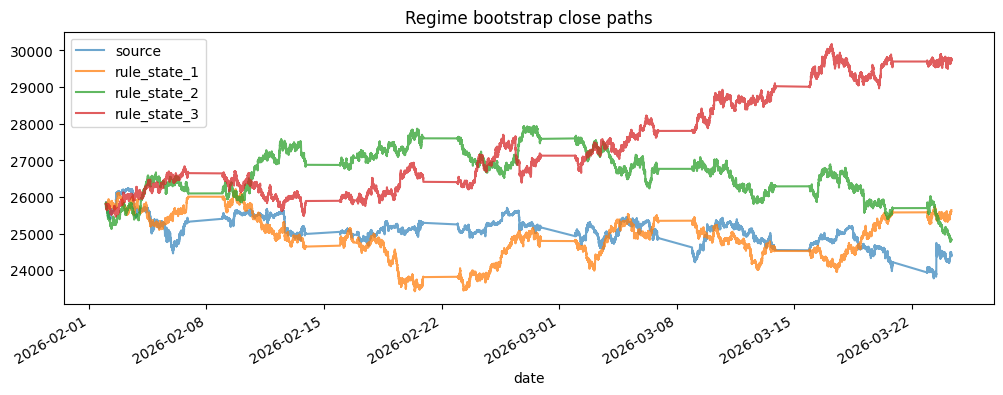

In [7]:
ax = df["close"].iloc[1:].rename("source").plot(
    figsize=(12, 4),
    alpha=0.65,
    grid=True,
    title="Regime bootstrap close paths",
)
for number, path in enumerate(regime_paths, start=1):
    path["close"].rename(f"rule_state_{number}").plot(ax=ax, alpha=0.75)
ax.legend()

## Quick exercise: build custom state inputs

You can combine any user-defined state series. The only requirement is that every generated bar has one non-null hashable label.

The practical checklist is:

1. Build the state labels.
2. Check bucket sizes with `value_counts()`.
3. Use relaxed `min_state_count` / `min_transition_count` only when you understand why the sample is small.

In [ ]:
custom_states = combine_states(
    return_states(df),
    range_states(df),
)

custom_paths = regime_bootstrap(
    df,
    states=custom_states,
    paths=1,
    random_state=11,
    min_state_count=20,
    min_transition_count=10,
)

custom_states.value_counts().head(), custom_paths[0].head()